In [ ]:
s = "hello geeks"
s1 = "H" + s[1:]
s2 = s.replace("geeks","GeeksforGeeks")
print(s1)
print(s2)


Hello geeks
hello GeeksforGeeks


In [ ]:
num = 12345
new_num = str(num).replace("123","321")
print(new_num)
print(type(new_num))

32145
<class 'str'>


In [ ]:
lst = [[1,2],[3,4],[5,6]]
for row in lst:
    for item in row:
        print(item)

1
2
3
4
5
6


In [1]:
import pandas as pd
marks = pd.Series([78, 85, 62, 90, 74], index=["Aarav","Diya","Kabir","Meera","Rohan"])
print(marks, "\n")
print("Meera :", marks["Meera"], "| Average :", marks.mean(), "| Topper :", marks.idxmax())

Aarav    78
Diya     85
Kabir    62
Meera    90
Rohan    74
dtype: int64 

Meera : 90 | Average : 77.8 | Topper : Meera


In [2]:
students = pd.DataFrame({
    "Name":  ["Aarav","Diya","Kabir","Meera","Rohan"],
    "City":  ["Pune","Delhi","Pune","Mumbai","Delhi"],
    "Marks": [78, 85, 62, 90, 74],
    "Fees_Paid": [True, True, False, True, False],
})
students

,Name,City,Marks,Fees_Paid
0,Aarav,Pune,78,True
1,Diya,Delhi,85,True
2,Kabir,Pune,62,False
3,Meera,Mumbai,90,True
4,Rohan,Delhi,74,False


In [3]:
print(students['Marks'].sum())
print(students['Marks'].max())


389
90


In [4]:
print("Shape:", students.shape)
print("Columns:", list(students.columns))
students.info()
students.describe()

Shape: (5, 4)
Columns: ['Name', 'City', 'Marks', 'Fees_Paid']
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Name       5 non-null      str  
 1   City       5 non-null      str  
 2   Marks      5 non-null      int64
 3   Fees_Paid  5 non-null      bool 
dtypes: bool(1), int64(1), str(2)
memory usage: 257.0 bytes


,Marks
count,5.00000
mean,77.80000
std,10.77961
min,62.00000
25%,74.00000
50%,78.00000
75%,85.00000
max,90.00000


In [5]:
print(students["Name"].tolist())
print(students.loc[3, "Name"])
print(students.iloc[0, 0])
students[["Name", "Marks"]].head(3)

['Aarav', 'Diya', 'Kabir', 'Meera', 'Rohan']
Meera
Aarav


,Name,Marks
0,Aarav,78
1,Diya,85
2,Kabir,62


In [6]:
students[["City","Marks"]].head (2)

,City,Marks
0,Pune,78
1,Delhi,85


In [7]:
students[(students["City"] == "Pune") & (students["Marks"] > 70)]

,Name,City,Marks,Fees_Paid
0,Aarav,Pune,78,True


In [8]:
import numpy as np
students["Result"] = np.where(students["Marks"] >= 75, "Distinction", "Pass")
students["Marks_out_of_10"] = students["Marks"] / 10
students

,Name,City,Marks,Fees_Paid,Result,Marks_out_of_10
0,Aarav,Pune,78,True,Distinction,7.8
1,Diya,Delhi,85,True,Distinction,8.5
2,Kabir,Pune,62,False,Pass,6.2
3,Meera,Mumbai,90,True,Distinction,9.0
4,Rohan,Delhi,74,False,Pass,7.4


In [9]:
students["Result"] = np.where(students["Marks"] >= 80, "A", "B")

In [10]:
students.groupby("City")["Marks"].mean().round(1)

City
Delhi     79.5
Mumbai    90.0
Pune      70.0
Name: Marks, dtype: float64

In [3]:
import numpy as np 
import pandas as pd
np.random.seed(42)
n = 3000
cities = {"Mumbai":"West","Delhi":"North","Bengaluru":"South","Hyderabad":"South",
          "Chennai":"South","Kolkata":"East","Pune":"West","Ahmedabad":"West",
          "Jaipur":"North","Lucknow":"North"}
cnames = list(cities); cw = np.array([16,15,13,9,9,8,9,7,7,7], float); cw /= cw.sum()
cats = {"Electronics":(["Smartphone","Laptop","Headphones","Smartwatch","Power Bank"], 3000, 80000),
        "Fashion":(["T-Shirt","Jeans","Sneakers","Kurta","Jacket"], 400, 6000),
        "Home & Kitchen":(["Mixer","Cookware Set","Bedsheet","Water Bottle","Table Lamp"], 300, 12000),
        "Books":(["Fiction","Textbook","Self-Help","Comics","Biography"], 150, 1500),
        "Grocery":(["Rice 5kg","Cooking Oil","Snacks Pack","Tea 500g","Coffee"], 100, 1200)}
clist = list(cats); cwt = [0.28,0.26,0.18,0.16,0.12]
alld = pd.date_range("2022-01-01","2023-12-31",freq="D")
w = np.ones(len(alld)); mth = alld.month
w[(mth==10)|(mth==11)] *= 2.2; w[mth==12] *= 1.4; w /= w.sum()
dates = pd.to_datetime(np.random.choice(alld, n, p=w))
cat = np.random.choice(clist, n, p=cwt)
prod, price = [], []
for c in cat:
    p, lo, hi = cats[c]
    prod.append(np.random.choice(p)); price.append(float(round(np.random.uniform(lo, hi))))
qty  = np.where(np.isin(cat, ["Grocery","Books"]), np.random.randint(1,6,n), np.random.randint(1,3,n))
disc = np.round(np.random.choice([0,0,0,0.05,0.1,0.15,0.2,0.3,0.4], n,
        p=[.30,.10,.10,.12,.12,.10,.08,.05,.03]), 2)
city = np.random.choice(cnames, n, p=cw)
df = pd.DataFrame({
    "OrderID":[f"ORD{100000+i}" for i in range(n)], "OrderDate":dates,
    "City":city, "Region":[cities[c] for c in city], "Category":cat, "Product":prod,
    "CustomerSegment":np.random.choice(["Regular","Premium","New"], n, p=[.55,.25,.20]),
    "Quantity":qty, "UnitPrice":price, "Discount":disc,
    "PaymentMethod":np.random.choice(["UPI","Credit Card","Debit Card","Cash on Delivery","Wallet"],
                                     n, p=[.42,.18,.15,.15,.10]),
    "Rating":np.random.choice([1,2,3,4,5,np.nan], n, p=[.03,.05,.15,.37,.33,.07]),
})
df.loc[df.sample(40, random_state=1).index, "City"] = np.nan
df = pd.concat([df, df.sample(25, random_state=2)], ignore_index=True)
df.to_csv("kartmart_orders.csv", index=False)
print("Saved kartmart_orders.csv")

Saved kartmart_orders.csv


In [4]:
orders = pd.read_csv("kartmart_orders.csv", parse_dates=["OrderDate"])
orders.head()

,OrderID,OrderDate,City,Region,Category,Product,CustomerSegment,Quantity,UnitPrice,Discount,PaymentMethod,Rating
0,ORD100000,2022-10-30,Delhi,North,Home & Kitchen,Mixer,Regular,1,6577.0,0.05,Debit Card,5.0
1,ORD100001,2023-11-30,Delhi,North,Books,Biography,Regular,2,1328.0,0.15,Credit Card,4.0
2,ORD100002,2023-07-29,Kolkata,East,Electronics,Smartwatch,Regular,2,49799.0,0.15,Credit Card,3.0
3,ORD100003,2023-03-30,Pune,West,Home & Kitchen,Mixer,Regular,2,11559.0,0.00,UPI,5.0
4,ORD100004,2022-05-21,Delhi,North,Home & Kitchen,Water Bottle,New,1,9222.0,0.20,UPI,4.0


In [5]:
print("Rows, Columns:", orders.shape)
orders.info()

Rows, Columns: (3025, 12)
<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          3025 non-null   str           
 1   OrderDate        3025 non-null   datetime64[us]
 2   City             2985 non-null   str           
 3   Region           3025 non-null   str           
 4   Category         3025 non-null   str           
 5   Product          3025 non-null   str           
 6   CustomerSegment  3025 non-null   str           
 7   Quantity         3025 non-null   int64         
 8   UnitPrice        3025 non-null   float64       
 9   Discount         3025 non-null   float64       
 10  PaymentMethod    3025 non-null   str           
 11  Rating           2850 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(7)
memory usage: 283.7 KB


In [6]:
orders.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,3025,3000,ORD100142,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderDate,3025,NaN,NaN,NaN,2023-01-24 07:36:30.942148,2022-01-01 00:00:00,2022-08-11 00:00:00,2023-01-04 00:00:00,2023-08-18 00:00:00,2023-12-31 00:00:00,NaN
City,2985,10,Mumbai,454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,3025,4,South,958,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3025,5,Electronics,869,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,3025,25,Smartwatch,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerSegment,3025,3,Regular,1612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,3025.0,NaN,NaN,NaN,1.902479,1.0,1.0,2.0,2.0,5.0,1.078934
UnitPrice,3025.0,NaN,NaN,NaN,14144.799669,103.0,1047.0,3953.0,13785.0,79947.0,21316.495984
Discount,3025.0,NaN,NaN,NaN,0.076777,0.0,0.0,0.05,0.15,0.4,0.100571


In [7]:
orders.isna()

,OrderID,OrderDate,City,Region,Category,Product,CustomerSegment,Quantity,UnitPrice,Discount,PaymentMethod,Rating
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3020,False,False,False,False,False,False,False,False,False,False,False,False
3021,False,False,False,False,False,False,False,False,False,False,False,False
3022,False,False,False,False,False,False,False,False,False,False,False,False
3023,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
orders.isnull().sum()


OrderID              0
OrderDate            0
City                40
Region               0
Category             0
Product              0
CustomerSegment      0
Quantity             0
UnitPrice            0
Discount             0
PaymentMethod        0
Rating             175
dtype: int64

In [9]:
orders["City"]

0           Delhi
1           Delhi
2         Kolkata
3            Pune
4           Delhi
          ...    
3020       Jaipur
3021    Bengaluru
3022    Hyderabad
3023        Delhi
3024         Pune
Name: City, Length: 3025, dtype: str

In [10]:
orders["City"] = orders["City"].fillna("Unknown")
print("Missing cities now:", orders["City"].isnull().sum())

Missing cities now: 0


In [11]:
print("Duplicate rows:", orders.duplicated().sum())
print("Before removing duplicates:", orders.shape)

Duplicate rows: 25
Before removing duplicates: (3025, 12)


In [12]:
orders = orders.drop_duplicates().reset_index(drop=True)
print("After removing duplicates:", orders.shape)

After removing duplicates: (3000, 12)


In [13]:
orders["Revenue"] = (orders["Quantity"] * orders["UnitPrice"] * (1 - orders["Discount"])).round(2)
orders["Month"]   = orders["OrderDate"].dt.to_period("M").astype(str)
orders["Weekday"] = orders["OrderDate"].dt.day_name()
orders["Festive"] = np.where(orders["OrderDate"].dt.month.isin([10, 11]), "Festive", "Regular")
orders[["OrderDate","Category","Quantity","UnitPrice","Discount","Revenue","Month","Festive"]].head()

,OrderDate,Category,Quantity,UnitPrice,Discount,Revenue,Month,Festive
0,2022-10-30,Home & Kitchen,1,6577.0,0.05,6248.15,2022-10,Festive
1,2023-11-30,Books,2,1328.0,0.15,2257.60,2023-11,Festive
2,2023-07-29,Electronics,2,49799.0,0.15,84658.30,2023-07,Regular
3,2023-03-30,Home & Kitchen,2,11559.0,0.00,23118.00,2023-03,Regular
4,2022-05-21,Home & Kitchen,1,9222.0,0.20,7377.60,2022-05,Regular


In [3]:
import pandas as pd
import numpy as np
orders = pd.read_csv("kartmart_orders.csv", parse_dates=["OrderDate"])
orders.head()
orders["Revenue"] = (
    orders["Quantity"] *
    orders["UnitPrice"] *
    (1 - orders["Discount"])
).round(2)

print("Total revenue  : ₹{:,.0f}".format(orders["Revenue"].sum()))
print("Total orders   : {:,}".format(len(orders)))
print("Avg order value: ₹{:,.0f}".format(orders["Revenue"].mean()))

Total revenue  : ₹60,989,779
Total orders   : 3,025
Avg order value: ₹20,162


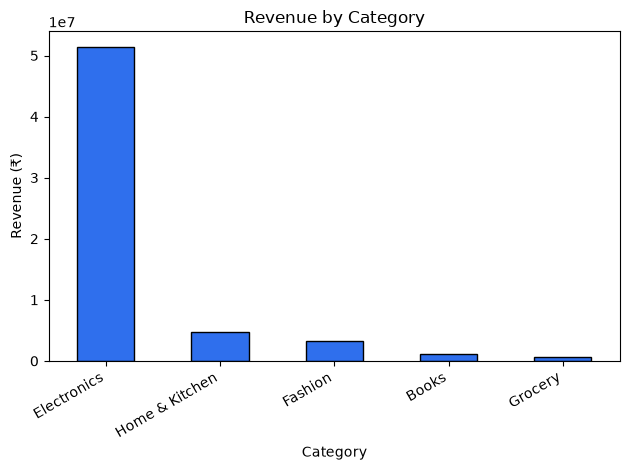

Category
Electronics       51388460.0
Home & Kitchen     4673123.0
Fashion            3250901.0
Books              1084541.0
Grocery             592753.0
Name: Revenue, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("kartmart_orders.csv", parse_dates=["OrderDate"])

orders["Revenue"] = (
    orders["Quantity"] *
    orders["UnitPrice"] *
    (1 - orders["Discount"])
).round(2)

cat_rev = orders.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

cat_rev.plot(kind="bar", color="#2f6fed", edgecolor="black")

plt.title("Revenue by Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(cat_rev.round(0))

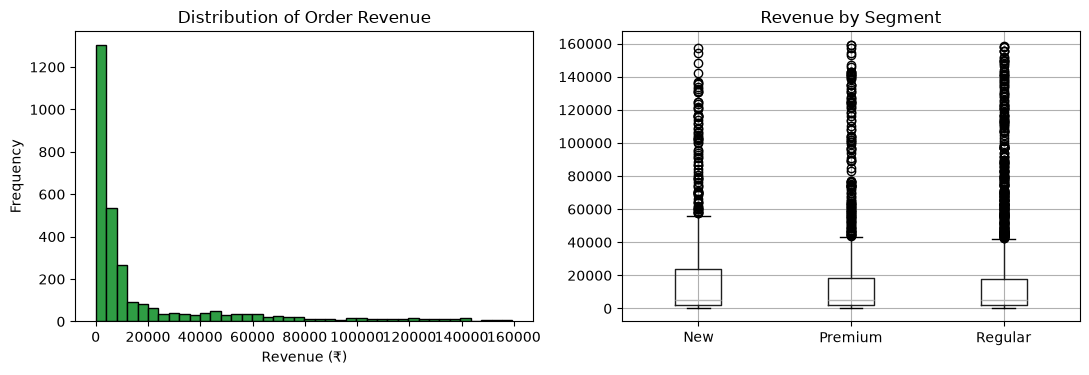

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
orders["Revenue"].plot(kind="hist", bins=40, ax=ax[0], color="#2f9e44", edgecolor="black")
ax[0].set_title("Distribution of Order Revenue"); ax[0].set_xlabel("Revenue (₹)")
orders.boxplot(column="Revenue", by="CustomerSegment", ax=ax[1])
ax[1].set_title("Revenue by Segment"); plt.suptitle(""); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

In [4]:
pivot = orders.pivot_table(index="Region", columns="CustomerSegment",
                           values="Revenue", aggfunc="sum").round(0)
pivot

CustomerSegment,New,Premium,Regular
Region,,,
East,1272560.0,825190.0,3150933.0
North,3442915.0,5869050.0,9044557.0
South,4116230.0,6152107.0,8001803.0
West,4343816.0,3877233.0,10893384.0


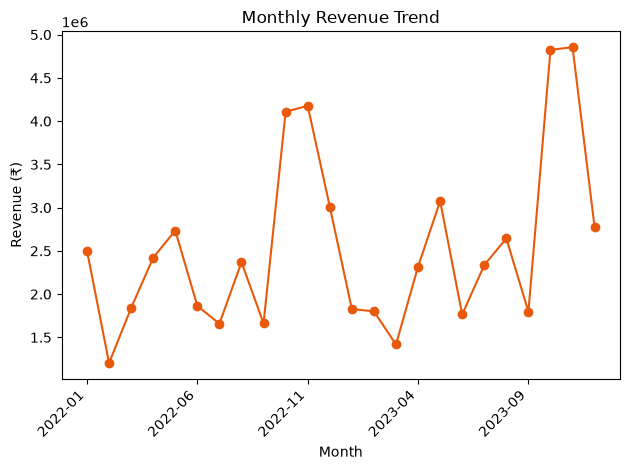

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
orders = pd.read_csv("kartmart_orders.csv")

# Convert OrderDate into datetime
orders["OrderDate"] = pd.to_datetime(orders["OrderDate"])

# Create Revenue column
orders["Revenue"] = (
    orders["Quantity"] *
    orders["UnitPrice"] *
    (1 - orders["Discount"])
).round(2)

# Create Month column
orders["Month"] = orders["OrderDate"].dt.to_period("M").astype(str)

# Monthly Revenue
monthly = orders.groupby("Month")["Revenue"].sum()

# Plot
monthly.plot(marker="o", color="#e8590c")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

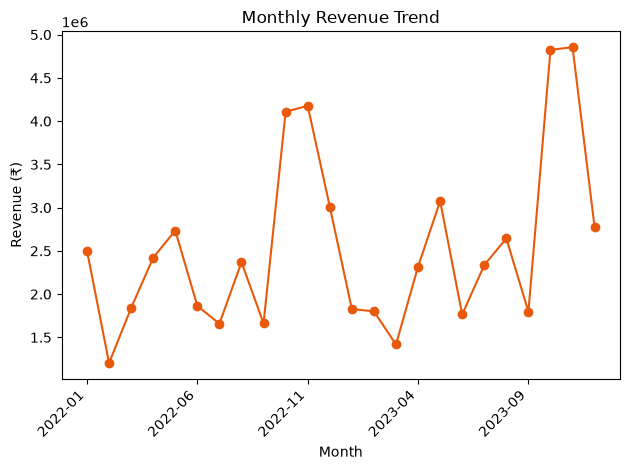

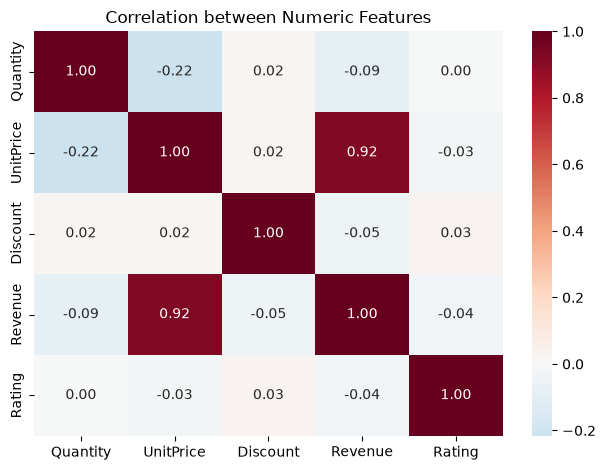

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
orders = pd.read_csv("kartmart_orders.csv")

# Convert OrderDate into datetime
orders["OrderDate"] = pd.to_datetime(orders["OrderDate"])

# Create Revenue column
orders["Revenue"] = (
    orders["Quantity"] *
    orders["UnitPrice"] *
    (1 - orders["Discount"])
).round(2)

# Create Month column
orders["Month"] = orders["OrderDate"].dt.to_period("M").astype(str)

# Monthly Revenue
monthly = orders.groupby("Month")["Revenue"].sum()

# Plot
monthly.plot(marker="o", color="#e8590c")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()
import seaborn as sns

HAS_SNS = True

num = orders[["Quantity", "UnitPrice", "Discount", "Revenue", "Rating"]]

corr = num.corr()

if HAS_SNS:
    sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
else:
    plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr)), corr.columns)
    plt.colorbar()

plt.title("Correlation between Numeric Features")
plt.tight_layout()
plt.show()